# Figure 11–14 Reproduction — §6.6 CP-Guided Plan Search

Reproduces the plan quality (Figure 11/12) and planning time (Figure 13/14)
comparisons from the paper, for all three checkpoints (50 / 100 / 150 iterations).

**Input**:
- `4-evaluation/CP/balsa{49,99,149}-True-{1..5}.log`
- `4-evaluation/NoCP/balsa{49,99,149}-False-{1..5}.log`

**Output**: `5-repro-figure11-14/figure{11,12,13,14}_{49,99,149}.png`


In [1]:
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

CP_DIR   = "./4-evaluation/CP"
NOCP_DIR = "./4-evaluation/NoCP"
OUT_DIR  = "./5-repro-figure11-14"
os.makedirs(OUT_DIR, exist_ok=True)

CHECKPOINTS = [49, 99, 149]
N_RUNS      = 5

TEST_QUERIES = [
    "1b",  "2b",  "3b",  "4b",  "5b",  "6b",  "7b",  "8b",  "9b",
    "10b", "11b", "12b", "13b", "14b", "15b", "16b", "17b", "18b",
    "19b", "20b", "21b", "22b", "23b", "24b", "25b", "26b", "27b",
    "28b", "29b", "30b", "31b", "32b", "33b",
]

# Paper query subsets — execution latency (Figure 11 / 12)
PAPER_EXEC = {
    49:  ["11b","18b","19b","1b","23b","24b","27b","31b","5b","7b","9b"],
    99:  ["14b","28b","6b","9b"],
    149: ["11b","18b","26b","7b"],
}

# Paper query subsets — planning time (Figure 13 / 14)
PAPER_PLAN = {
    49:  ["14b","22b","25b","29b","33b","3b","4b","5b","6b","7b","8b"],
    99:  [],
    149: ["12b","14b","15b","16b","17b","18b","1b","22b","25b",
          "27b","28b","29b","31b","33b","3b","7b","8b"],
}


In [2]:
def parse_log(file_path):
    """
    Parse a single Balsa evaluation log and return a DataFrame
    with columns: SQL_Name, Execution_Time, Predicted_Execution, Planning_Time.
    """
    with open(file_path) as f:
        content = f.read()
    lines = content.split("\n")

    predicted_times = {}
    actual_times    = {}
    planning_times  = {}

    i = 0
    while i < len(lines):
        line = lines[i]

        # Planning time
        m = re.search(r"Planning took ([\d.]+)ms", line)
        if m:
            plan_ms = float(m.group(1))
            for j in range(i + 1, min(i + 3, len(lines))):
                qm = re.search(r"\[Test set\] q(\w+), predicted time: ([\d.]+)", lines[j])
                if qm and qm.group(1) in TEST_QUERIES:
                    qname = qm.group(1)
                    planning_times[qname]  = plan_ms
                    predicted_times[qname] = float(qm.group(2))
                    break

        # Actual execution time
        m = re.search(r"Actual run time for (\w+)", line)
        if m:
            qname = m.group(1)
            if qname in TEST_QUERIES and i + 1 < len(lines):
                tm = re.search(r"Actual Total Time: ([\d.]+)", lines[i + 1])
                if tm:
                    actual_times[qname] = float(tm.group(1))
        i += 1

    rows = []
    for q in TEST_QUERIES:
        if q in predicted_times and q in actual_times:
            rows.append((q, actual_times[q], predicted_times[q],
                         planning_times.get(q, float("nan"))))

    return pd.DataFrame(rows, columns=[
        "SQL_Name", "Execution_Time", "Predicted_Execution", "Planning_Time"
    ])


def load_checkpoint(ckpt, n_runs=N_RUNS):
    """
    Load CP and NoCP logs for a checkpoint, average over n_runs,
    and compute Improvement and Planning_Improvement ratios.
    """
    cp_runs   = []
    nocp_runs = []

    for i in range(1, n_runs + 1):
        cp_runs.append(
            parse_log(f"{CP_DIR}/balsa{ckpt}-True-{i}.log").set_index("SQL_Name"))
        nocp_runs.append(
            parse_log(f"{NOCP_DIR}/balsa{ckpt}-False-{i}.log").set_index("SQL_Name"))

    avg_cp   = pd.concat(cp_runs).groupby("SQL_Name").mean()
    avg_nocp = pd.concat(nocp_runs).groupby("SQL_Name").mean()

    df = pd.concat([avg_cp, avg_nocp], axis=1, keys=["CP", "NoCP"])

    df["Improvement"]         = (df[("NoCP","Execution_Time")] /
                                  df[("CP","Execution_Time")]).round(2)
    df["Planning_Improvement"]= (df[("NoCP","Planning_Time")] /
                                  df[("CP","Planning_Time")]).round(3)

    df = df.sort_values("Improvement", ascending=False).reset_index()
    return df


def flatten(df):
    d = df.copy()
    d.columns = ["_".join(c).strip("_") if isinstance(c, tuple) else c
                 for c in d.columns]
    return d


def print_summary(df, ckpt):
    f = flatten(df)
    total    = len(f)
    improved = (f["Improvement"] > 1.05).sum()
    worse    = (f["Improvement"] < 0.95).sum()
    same     = total - improved - worse

    total_cp   = f["CP_Planning_Time"].sum()
    total_nocp = f["NoCP_Planning_Time"].sum()
    reduction  = (1 - total_cp / total_nocp) * 100

    print(f"checkpoint_{ckpt}  ({total} queries, avg of {N_RUNS} runs)")
    print(f"  Execution: CP better={improved} ({improved/total*100:.1f}%)  "
          f"similar={same}  worse={worse} ({worse/total*100:.1f}%)")
    print(f"  Planning : total CP={total_cp:.1f}ms  NoCP={total_nocp:.1f}ms  "
          f"reduction={reduction:.2f}%")


## Load Evaluation Logs

In [3]:
data = {}
for ckpt in CHECKPOINTS:
    print(f"Loading checkpoint_{ckpt}...")
    data[ckpt] = load_checkpoint(ckpt)
    print_summary(data[ckpt], ckpt)
    print()


Loading checkpoint_49...
checkpoint_49  (33 queries, avg of 5 runs)
  Execution: CP better=20 (60.6%)  similar=3  worse=10 (30.3%)
  Planning : total CP=14916.3ms  NoCP=17381.6ms  reduction=14.18%

Loading checkpoint_99...
checkpoint_99  (33 queries, avg of 5 runs)
  Execution: CP better=12 (36.4%)  similar=6  worse=15 (45.5%)
  Planning : total CP=16425.3ms  NoCP=18410.1ms  reduction=10.78%

Loading checkpoint_149...
checkpoint_149  (33 queries, avg of 5 runs)
  Execution: CP better=22 (66.7%)  similar=1  worse=10 (30.3%)
  Planning : total CP=15110.0ms  NoCP=21185.0ms  reduction=28.68%



## Plot Helpers

In [4]:
def bar_plot(d, title, y_cp, y_nocp, ylabel, out_path,
              queries=None, paper_plus_extra=False,
              extra_condition=None, figsize=(14, 5)):
    """
    Generic grouped bar chart: CP (dark blue) vs Without CP (light blue).

    Args:
        d                : flattened DataFrame
        title            : plot title
        y_cp / y_nocp    : column names for CP and NoCP values
        ylabel           : y-axis label
        out_path         : file path to save PNG (None = do not save)
        queries          : list of query names to show (None = all)
        paper_plus_extra : if True, show paper queries + extra improved queries
        extra_condition  : lambda(df) → bool mask for "extra" queries
        figsize          : figure size
    """
    if paper_plus_extra and queries:
        d_paper = d[d["SQL_Name"].isin(queries)].copy()
        d_paper["_order"] = d_paper["SQL_Name"].apply(queries.index)
        d_paper = d_paper.sort_values("_order")

        extra_mask = extra_condition(d) if extra_condition else (
            (d["Improvement"] > 1.05) & (~d["SQL_Name"].isin(queries))
        )
        d_extra = d[extra_mask].copy()
        d_extra["_sort"] = d_extra["SQL_Name"].apply(lambda x: int(x[:-1]))
        d_extra = d_extra.sort_values("_sort")

        split_idx = len(d_paper)
        d_plot = pd.concat([d_paper, d_extra], ignore_index=True)
    else:
        if queries:
            d_plot = d[d["SQL_Name"].isin(queries)].copy()
            d_plot["_order"] = d_plot["SQL_Name"].apply(
                lambda x: queries.index(x) if x in queries else 999)
            d_plot = d_plot.sort_values("_order")
        else:
            d_plot = d.copy()
            d_plot["_sort"] = d_plot["SQL_Name"].apply(lambda x: int(x[:-1]))
            d_plot = d_plot.sort_values("_sort")
        split_idx = None

    d_plot = d_plot.reset_index(drop=True)
    x = np.arange(len(d_plot))
    w = 0.35

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x - w/2, d_plot[y_cp],   w, label="CP-Guided",  color="#1a5fa8")
    ax.bar(x + w/2, d_plot[y_nocp], w, label="Without CP", color="#93b8d9")

    if split_idx is not None:
        ax.axvline(split_idx - 0.5, linestyle="--", alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(d_plot["SQL_Name"], rotation=0, ha="center")
    ax.set_xlabel("Query")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{v/1000:.1f}k" if v >= 1000 else f"{v:.0f}"
    ))
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {out_path}")
    plt.show()


## Figure 11 & 12 — Plan Quality: Execution Latency

- **Figure 11** (paper): checkpoint_49, paper query subset
- **Figure 12a** (paper): checkpoint_99, paper query subset
- **Figure 12b** (paper): checkpoint_149, paper query subset


Saved → ./5-repro-figure11-14/figure11_12_49_all.png


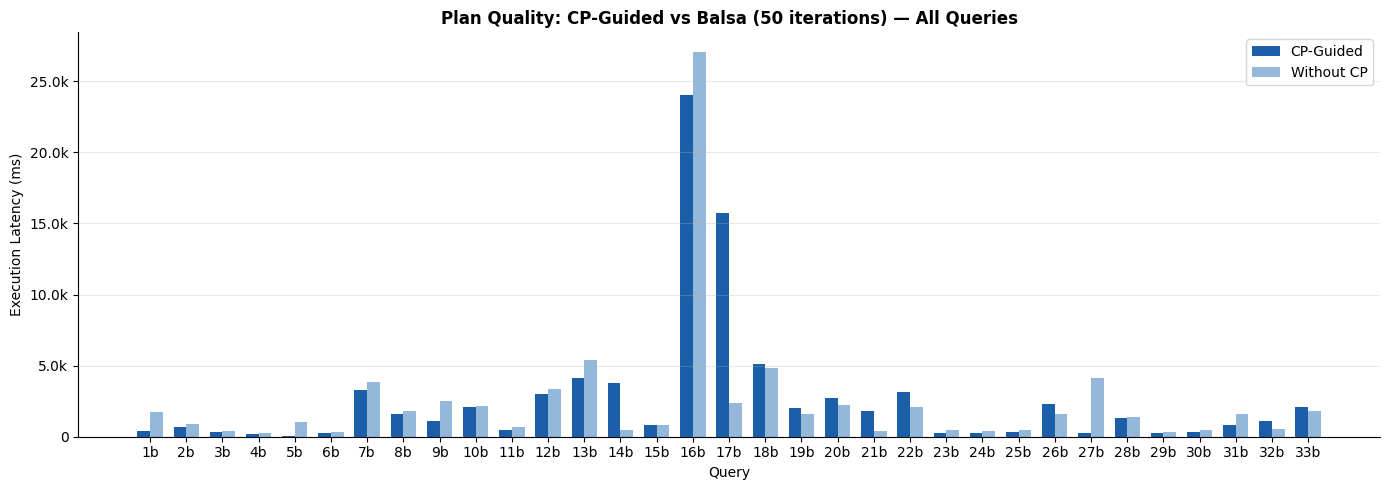

Saved → ./5-repro-figure11-14/figure11_12_49_paper.png


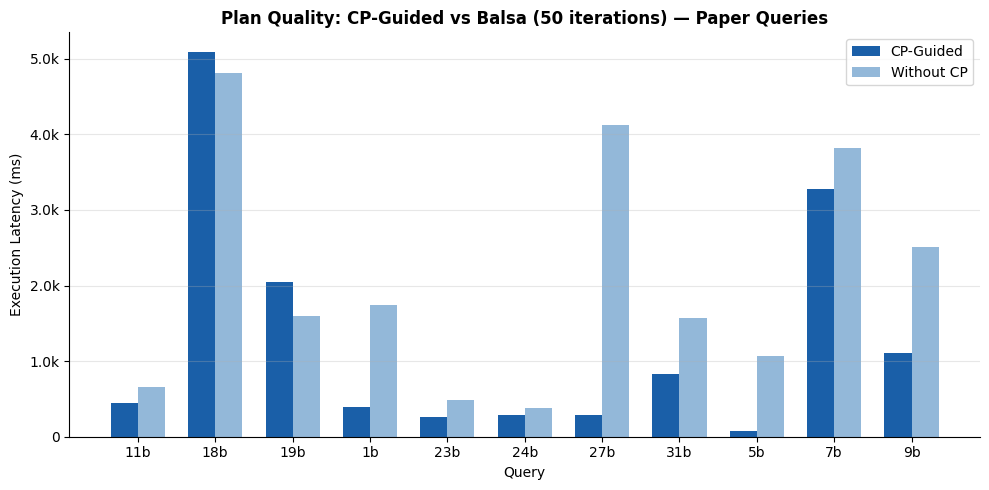

Saved → ./5-repro-figure11-14/figure11_12_49_paper_plus.png


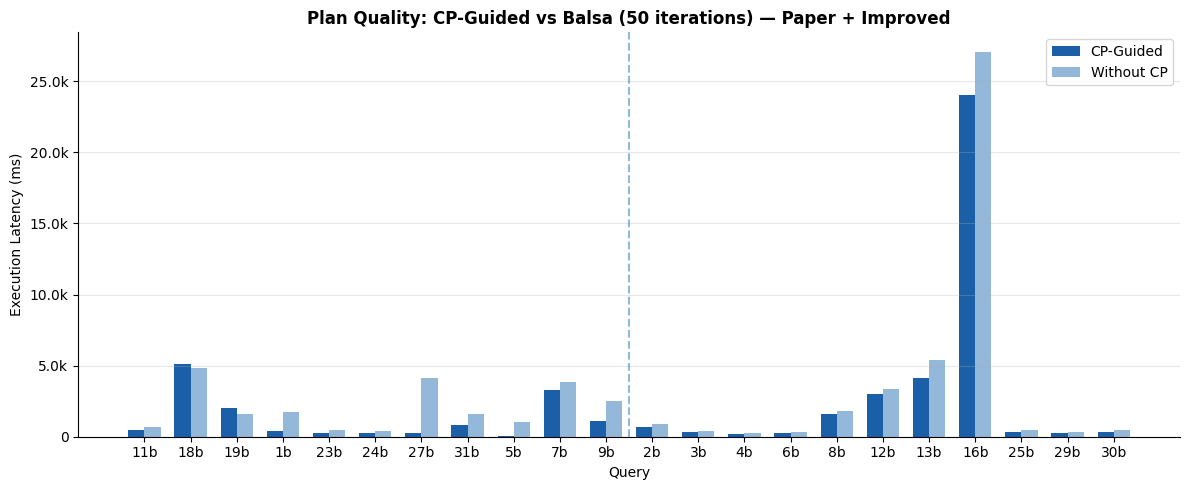

Saved → ./5-repro-figure11-14/figure11_12_99_all.png


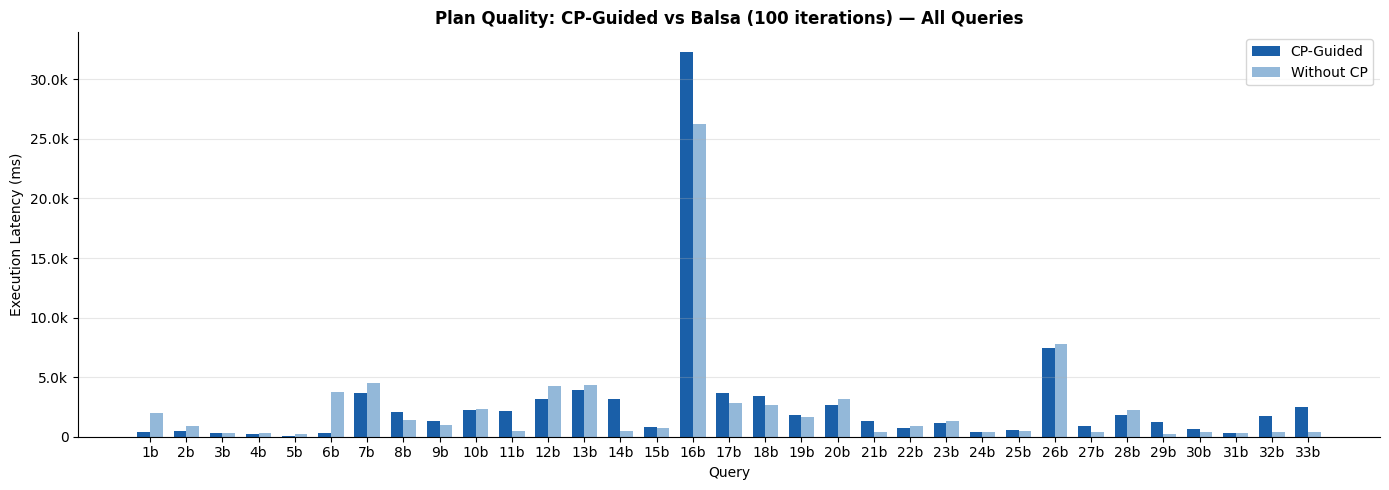

Saved → ./5-repro-figure11-14/figure11_12_99_paper.png


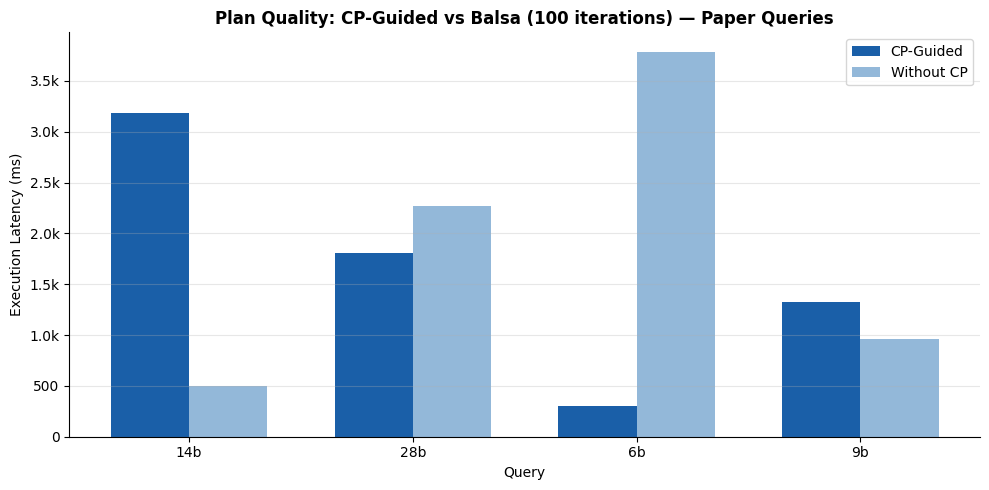

Saved → ./5-repro-figure11-14/figure11_12_99_paper_plus.png


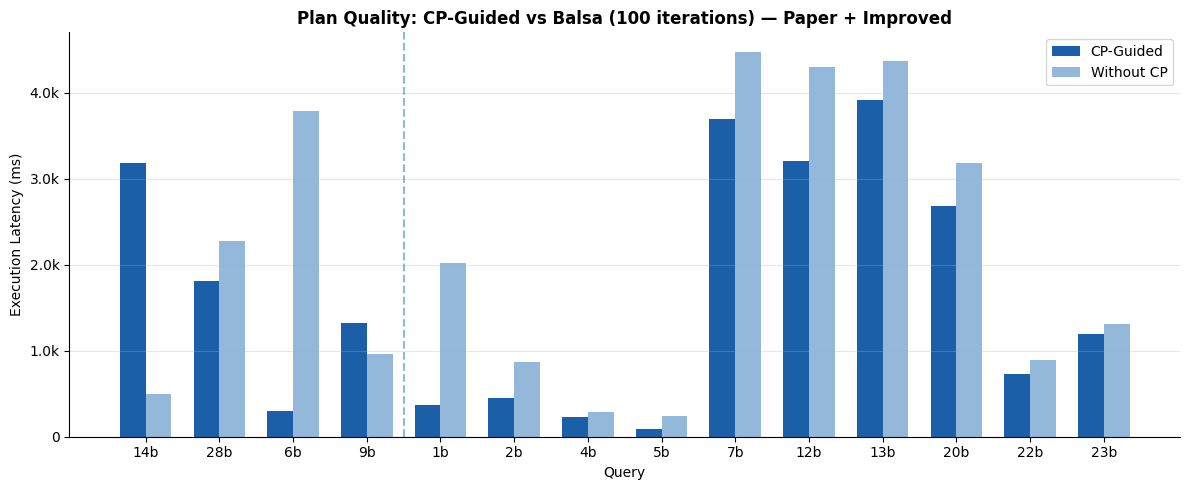

Saved → ./5-repro-figure11-14/figure11_12_149_all.png


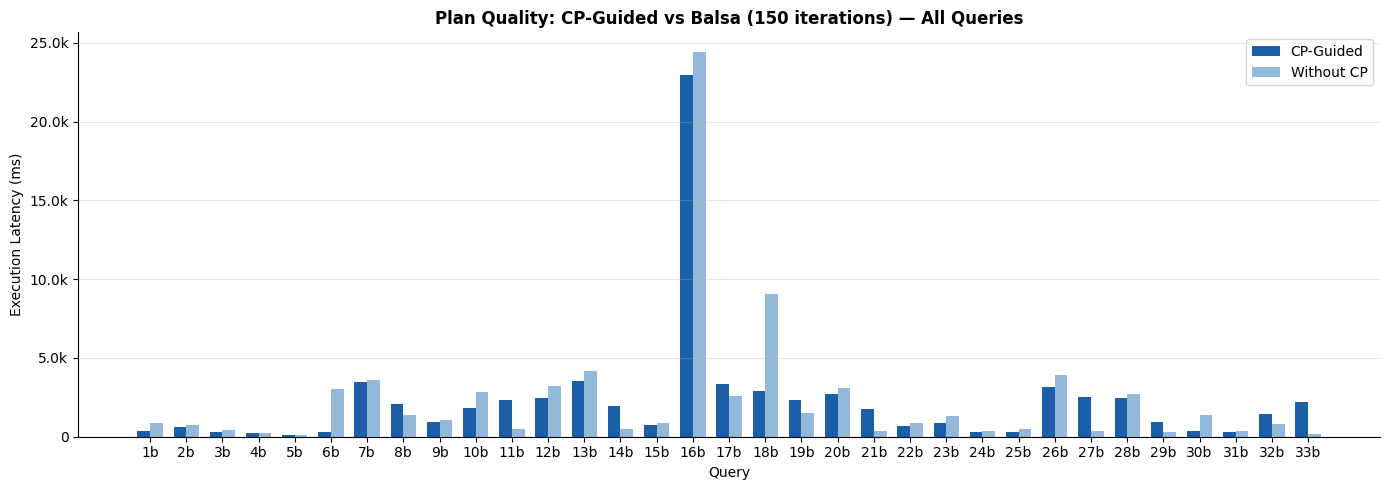

Saved → ./5-repro-figure11-14/figure11_12_149_paper.png


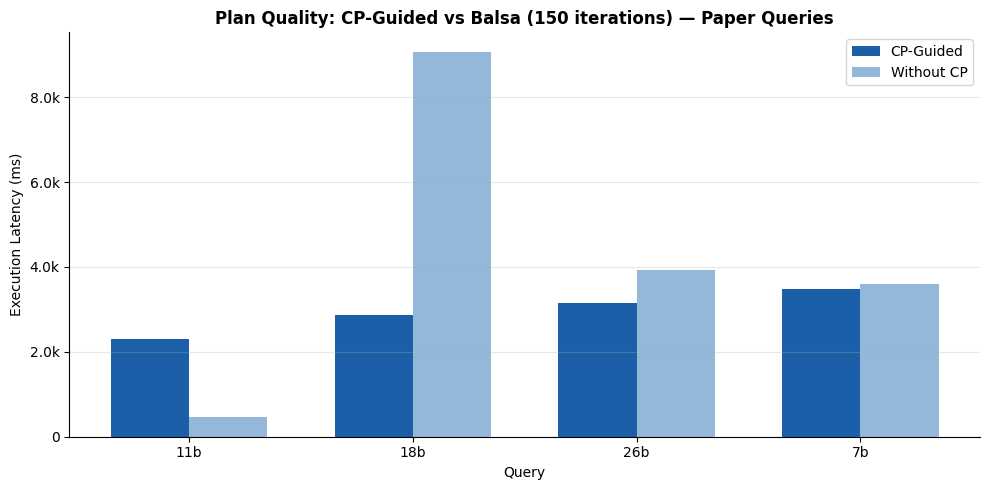

Saved → ./5-repro-figure11-14/figure11_12_149_paper_plus.png


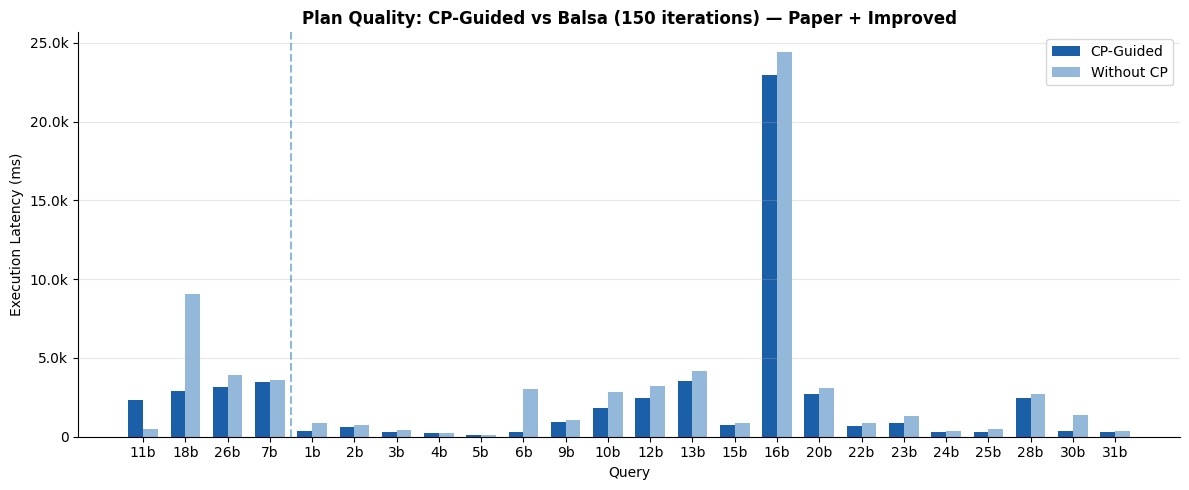

In [5]:
ITER_LABEL = {49: "50 iterations", 99: "100 iterations", 149: "150 iterations"}

for ckpt in CHECKPOINTS:
    f = flatten(data[ckpt])
    label = ITER_LABEL[ckpt]
    paper_q = PAPER_EXEC[ckpt]

    # All queries
    bar_plot(f, f"Plan Quality: CP-Guided vs Balsa ({label}) — All Queries",
             "CP_Execution_Time", "NoCP_Execution_Time",
             "Execution Latency (ms)",
             os.path.join(OUT_DIR, f"figure11_12_{ckpt}_all.png"))

    # Paper queries only (reproduces Figure 11 / 12 exactly)
    if paper_q:
        bar_plot(f, f"Plan Quality: CP-Guided vs Balsa ({label}) — Paper Queries",
                 "CP_Execution_Time", "NoCP_Execution_Time",
                 "Execution Latency (ms)",
                 os.path.join(OUT_DIR, f"figure11_12_{ckpt}_paper.png"),
                 queries=paper_q, figsize=(10, 5))

    # Paper queries + additional improved queries
    bar_plot(f, f"Plan Quality: CP-Guided vs Balsa ({label}) — Paper + Improved",
             "CP_Execution_Time", "NoCP_Execution_Time",
             "Execution Latency (ms)",
             os.path.join(OUT_DIR, f"figure11_12_{ckpt}_paper_plus.png"),
             queries=paper_q, paper_plus_extra=True, figsize=(12, 5))


## Figure 13 & 14 — Planning Time

- **Figure 13** (paper): checkpoint_49, paper query subset
- **Figure 14** (paper): checkpoint_149, paper query subset


Saved → ./5-repro-figure11-14/figure13_14_49_all.png


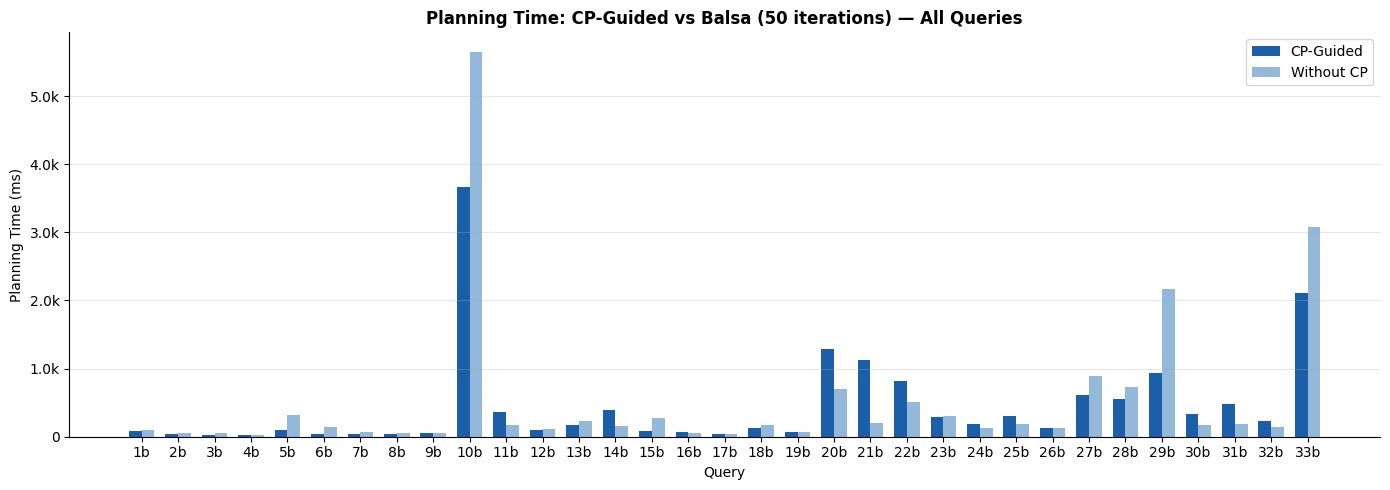

Saved → ./5-repro-figure11-14/figure13_14_49_paper.png


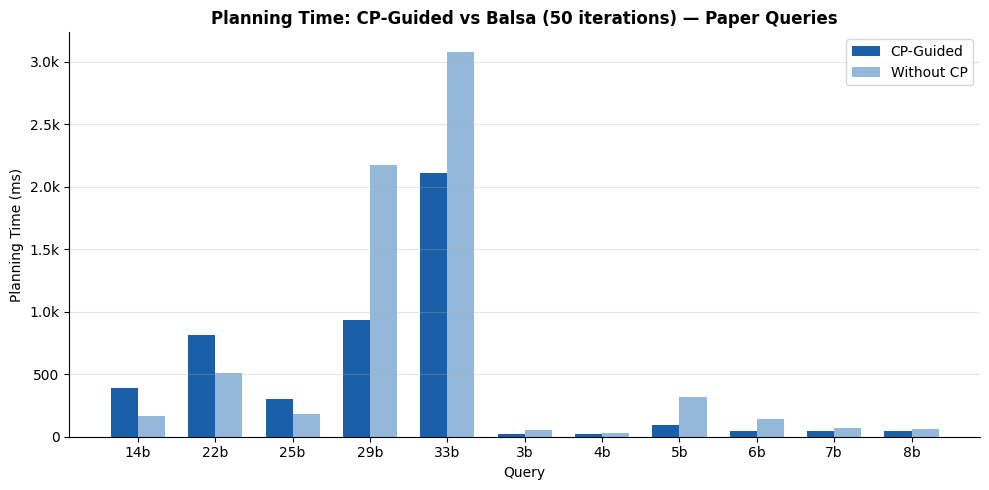

Saved → ./5-repro-figure11-14/figure13_14_49_paper_plus.png


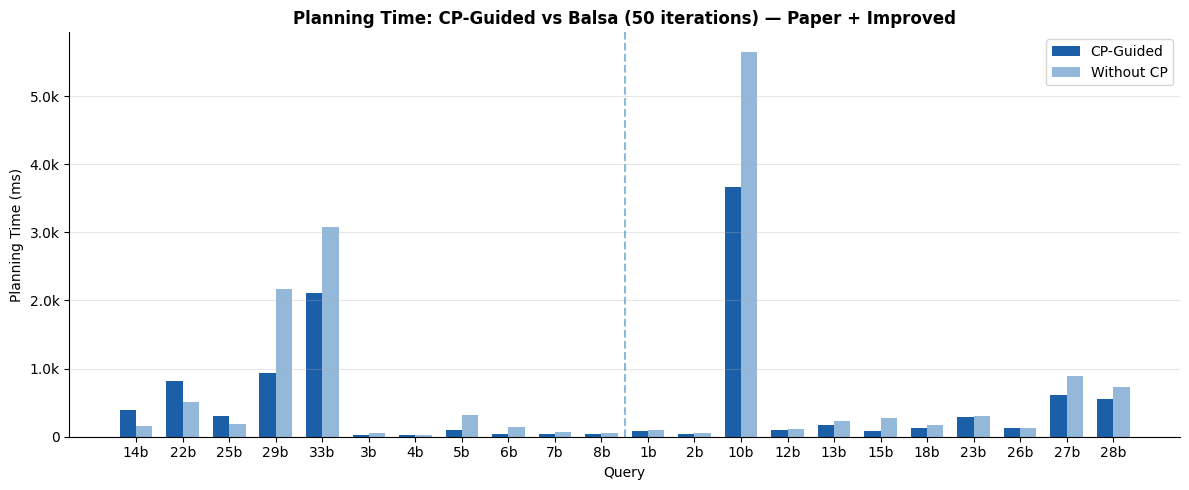

Saved → ./5-repro-figure11-14/figure13_14_99_all.png


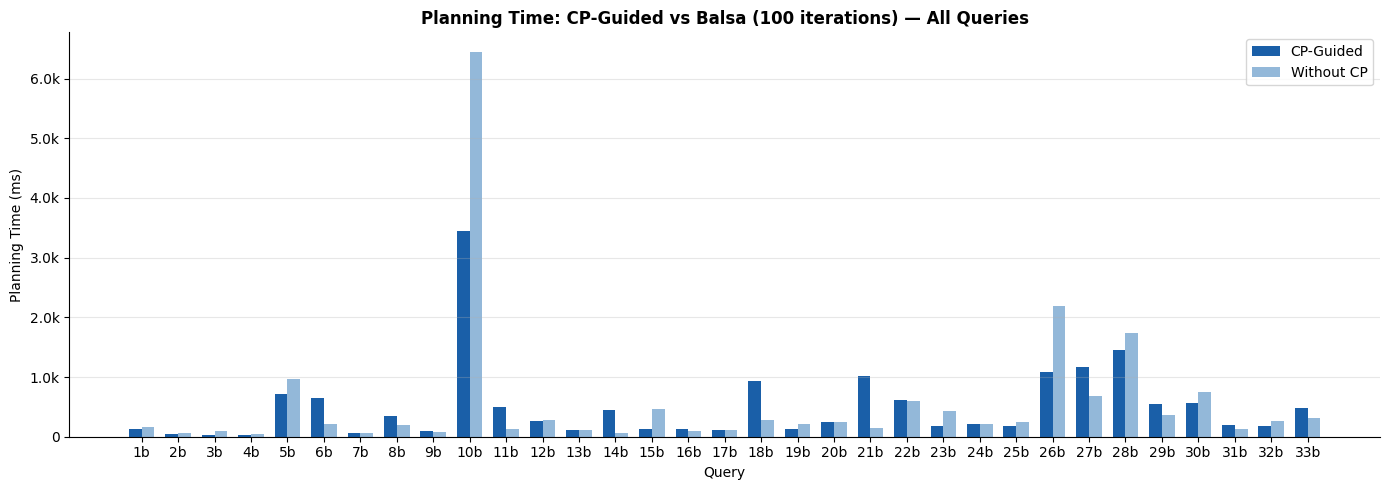

Saved → ./5-repro-figure11-14/figure13_14_149_all.png


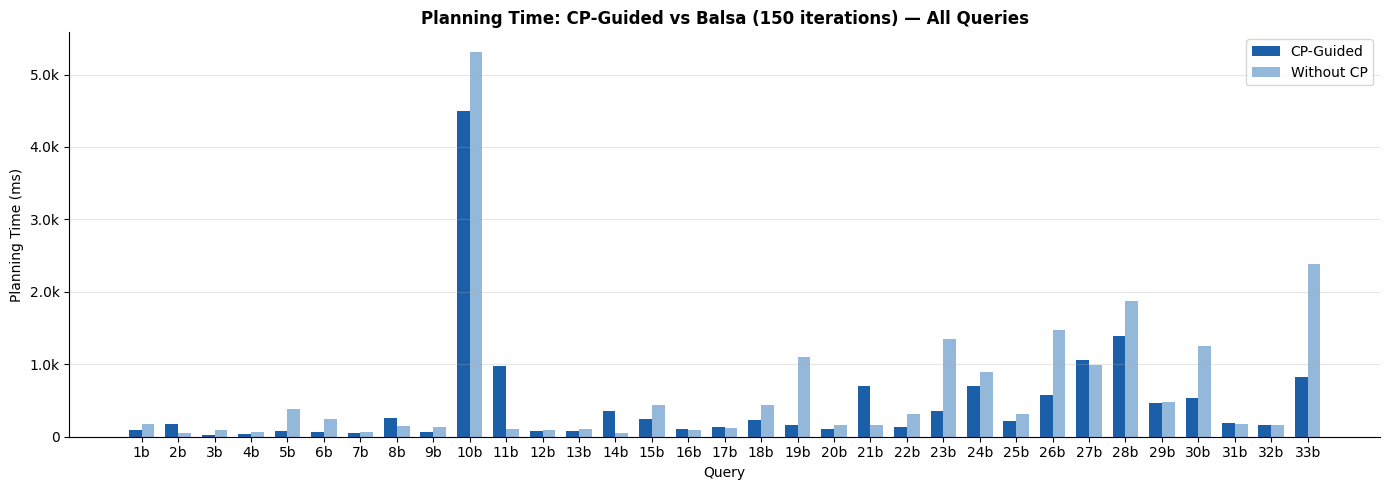

Saved → ./5-repro-figure11-14/figure13_14_149_paper.png


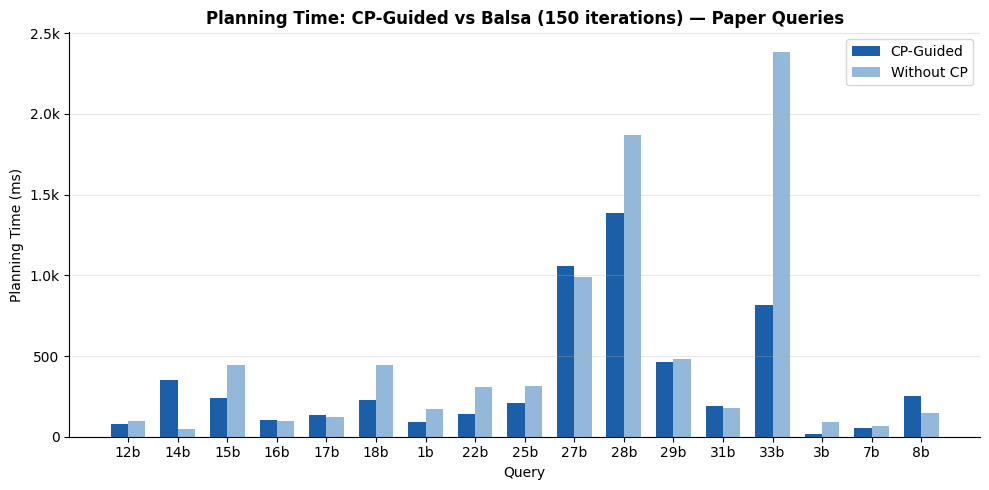

Saved → ./5-repro-figure11-14/figure13_14_149_paper_plus.png


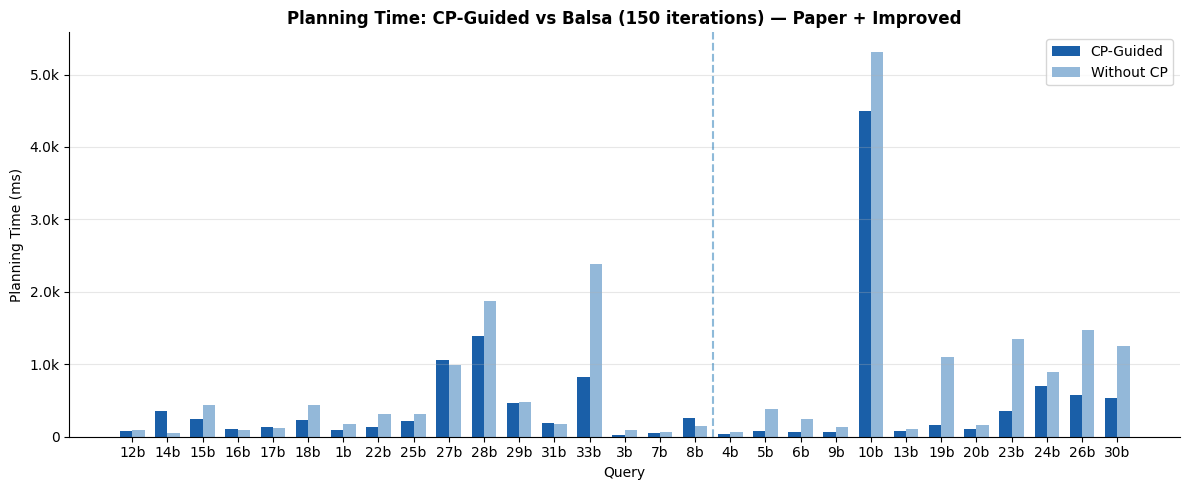

In [6]:
for ckpt in CHECKPOINTS:
    f = flatten(data[ckpt])
    label = ITER_LABEL[ckpt]
    paper_q = PAPER_PLAN[ckpt]

    # All queries
    bar_plot(f, f"Planning Time: CP-Guided vs Balsa ({label}) — All Queries",
             "CP_Planning_Time", "NoCP_Planning_Time",
             "Planning Time (ms)",
             os.path.join(OUT_DIR, f"figure13_14_{ckpt}_all.png"))

    # Paper queries only
    if paper_q:
        bar_plot(f, f"Planning Time: CP-Guided vs Balsa ({label}) — Paper Queries",
                 "CP_Planning_Time", "NoCP_Planning_Time",
                 "Planning Time (ms)",
                 os.path.join(OUT_DIR, f"figure13_14_{ckpt}_paper.png"),
                 queries=paper_q, figsize=(10, 5))

        # Paper + improved planning time queries
        bar_plot(f, f"Planning Time: CP-Guided vs Balsa ({label}) — Paper + Improved",
                 "CP_Planning_Time", "NoCP_Planning_Time",
                 "Planning Time (ms)",
                 os.path.join(OUT_DIR, f"figure13_14_{ckpt}_paper_plus.png"),
                 queries=paper_q, paper_plus_extra=True,
                 extra_condition=lambda d: (
                     (d["Planning_Improvement"] > 1.05) &
                     (~d["SQL_Name"].isin(paper_q))
                 ),
                 figsize=(12, 5))
